In [1]:
import os
import numpy as np
import random
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

import monai
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd, Spacingd, Resized, RandFlipd,
    RandRotate90d, RandShiftIntensityd, ToTensord, EnsureTyped
)
from monai.data import Dataset, CacheDataset, decollate_batch
from monai.networks.nets import UNet, SwinUNETR
from monai.losses import DiceLoss
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.transforms import AsDiscrete
from monai.inferers import sliding_window_inference

import SimpleITK as sitk  # used in your notebook earlier
import joblib
import time

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
You are using a Python version (3.10.10) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.


In [2]:
# ----------------------
# CONFIG (edit paths/sizes/batches for your environment)
# ----------------------
CONFIG = {
    "paths": {
        "task1_unlabeled_dir": "K:\dharaneesh\dharaneesh\csv_lists\\task1_unlabeled.csv",   # directory or csv describing unlabeled T1 volumes
        "task1_train_csv": "K:\dharaneesh\dharaneesh\csv_lists\\task1_train.csv",
        "task1_val_csv":   "K:\dharaneesh\dharaneesh\csv_lists\\task1_val.csv",
        "task2_train_csv": "K:\dharaneesh\dharaneesh\csv_lists\\task2_train.csv",
        "task2_val_csv":   "K:\dharaneesh\dharaneesh\csv_lists\\task2_val.csv",
        "save_dir": "./models"
    },
    "img_size": (128, 128, 128),   # resize/resample target shape (z,y,x) or (d,h,w)
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "batch_size": 2,
    "ssl_epochs": 30,
    "sup_epochs": 40,
    "task2_epochs": 30,
    "lr": 1e-4,
    "seed": 42
}

os.makedirs(CONFIG["paths"]["save_dir"], exist_ok=True)

In [3]:
# ----------------------
# seed
# ----------------------
def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

seed_everything(CONFIG["seed"])

In [4]:
import pandas as pd
def csv_to_monai_list(csv_path):
    df = pd.read_csv(csv_path, header=None)
    pairs = []
    for _, row in df.iterrows():
        img, lbl = str(row[0]), str(row[1])
        pairs.append({"image": img, "label": lbl})
    return pairs

In [5]:
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd,
    Resized, RandFlipd, RandRotate90d, RandShiftIntensityd,
    ToTensord, Lambdad, CastToTyped
)
import torch

# ✅ define this once so it's picklable
def cast_to_int32(x):
    return x.astype("int32")


def get_transforms(img_size, mode="train"):
    if mode == "train":
        tr = Compose([
            LoadImaged(keys=["image", "label"]),   # 👈 removed reader
            EnsureChannelFirstd(keys=["image", "label"]),
            ScaleIntensityd(keys=["image"]),
            Lambdad(keys=["label"], func=cast_to_int32),
            Resized(keys=["image","label"], spatial_size=img_size, mode=("trilinear","nearest")),
            RandFlipd(keys=["image","label"], prob=0.5, spatial_axis=0),
            RandRotate90d(keys=["image","label"], prob=0.5, max_k=3),
            RandShiftIntensityd(keys=["image"], offsets=0.1, prob=0.5),
            ToTensord(keys=["image","label"])
        ])
    else:
        tr = Compose([
            LoadImaged(keys=["image","label"]),   # 👈 removed reader
            EnsureChannelFirstd(keys=["image","label"]),
            ScaleIntensityd(keys=["image"]),
            Lambdad(keys=["label"], func=cast_to_int32),
            Resized(keys=["image","label"], spatial_size=img_size, mode=("trilinear","nearest")),
            ToTensord(keys=["image","label"])
        ])
    return tr


def get_ssl_transforms(img_size, train=True):
    if train:
        tr = Compose([
            LoadImaged(keys=["image"]),   # 👈 removed reader
            EnsureChannelFirstd(keys=["image"]),
            ScaleIntensityd(keys=["image"]),
            Resized(keys=["image"], spatial_size=img_size),
            RandFlipd(keys=["image"], prob=0.5, spatial_axis=0),
            RandRotate90d(keys=["image"], prob=0.5, max_k=3),
            RandShiftIntensityd(keys=["image"], offsets=0.1, prob=0.5),
            ToTensord(keys=["image"])
        ])
    else:
        tr = Compose([
            LoadImaged(keys=["image"]),   # 👈 removed reader
            EnsureChannelFirstd(keys=["image"]),
            ScaleIntensityd(keys=["image"]),
            Resized(keys=["image"], spatial_size=img_size),
            ToTensord(keys=["image"])
        ])
    return tr



In [6]:
# ----------------------
# Data loaders
# ----------------------
def make_loader_from_pairs(pairs, transforms, batch_size=CONFIG["batch_size"], shuffle=True, cache=False):
    if cache:
        ds = CacheDataset(data=pairs, transform=transforms, cache_rate=1.0)
    else:
        ds = Dataset(data=pairs, transform=transforms)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=True)
    return dl

In [7]:
def random_mask_volume(x, mask_ratio=0.25):
    # x: tensor (B,C,D,H,W)
    B,C,D,H,W = x.shape
    total = D*H*W
    num_mask = int(total * mask_ratio)
    x_masked = x.clone()
    masks = torch.ones_like(x)
    for b in range(B):
        idx = torch.randperm(total)[:num_mask]
        flat = x_masked[b].view(-1)
        flat[idx] = 0.0
        masks[b].view(-1)[idx] = 0.0
    return x_masked, masks

In [8]:
import pandas as pd
from monai.data import Dataset, DataLoader

# pick one file from csv
df = pd.read_csv(r"K:\dharaneesh\dharaneesh\\csv_lists\\task1_train.csv")
sample = [{"image": df.iloc[0,0], "label": df.iloc[0,1]}]

# supervised test
ds = Dataset(data=sample, transform=get_transforms(CONFIG["img_size"], mode="train"))
dl = DataLoader(ds, batch_size=1)

batch = next(iter(dl))
print("Supervised shapes:", batch["image"].shape, batch["label"].shape, batch["label"].dtype)

# ssl test
df_ssl = pd.read_csv(r"K:\dharaneesh\dharaneesh\\csv_lists\\task1_unlabeled.csv")
sample_ssl = [{"image": df_ssl.iloc[0,0]}]

ds_ssl = Dataset(data=sample_ssl, transform=get_ssl_transforms(CONFIG["img_size"], train=True))
dl_ssl = DataLoader(ds_ssl, batch_size=1)

batch_ssl = next(iter(dl_ssl))
print("SSL shapes:", batch_ssl["image"].shape)


Supervised shapes: torch.Size([1, 1, 128, 128, 128]) torch.Size([1, 1, 128, 128, 128]) torch.float32
SSL shapes: torch.Size([1, 1, 128, 128, 128])


In [9]:
def ssl_pretrain_autoencoder(unlabeled_pairs, img_size=CONFIG["img_size"], epochs=10, lr=1e-4, device=CONFIG["device"], save_path=None):
    print("Start SSL pretraining (autoencoder reconstruction)...")
    tr = get_ssl_transforms(img_size, train=True)
    dl = make_loader_from_pairs(unlabeled_pairs, tr, batch_size=CONFIG["batch_size"], shuffle=True, cache=False)
    # Use UNet as autoencoder (in_channels=1, out_channels=1)
    ae = UNet(
        spatial_dims=3,
        in_channels=1,
        out_channels=1,
        channels=(16,32,64,128,256),
        strides=(2,2,2,2),
        num_res_units=2
    ).to(device)

    opt = torch.optim. Adam(ae.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = {"loss": []}
    for epoch in range(epochs):
        ae.train()
        epoch_loss = 0.0
        steps = 0
        t0 = time.time()
        for batch in dl:
            imgs = batch["image"].to(device).float()
            imgs_masked, mask = random_mask_volume(imgs, mask_ratio=0.3)
            preds = ae(imgs_masked)
            loss = criterion(preds * (1-mask), imgs * (1-mask))  # reconstruct masked region (alternative: full mse)
            opt.zero_grad(); loss.backward(); opt.step()
            epoch_loss += loss.item(); steps += 1
        avg = epoch_loss/steps
        history["loss"].append(avg)
        print(f"SSL Epoch {epoch+1}/{epochs}  loss={avg:.6f}  time={(time.time()-t0):.1f}s")
    if save_path:
        torch.save(ae.state_dict(), save_path)
        print("Saved SSL model to", save_path)
    return ae, history

In [10]:
def build_segmentation_unet(img_size=CONFIG["img_size"], in_channels=1, out_channels=1, device=CONFIG["device"]):
    model = UNet(
        spatial_dims=3,
        in_channels=in_channels,
        out_channels=out_channels,
        channels=(16,32,64,128,256),
        strides=(2,2,2,2),
        num_res_units=2
    ).to(device)
    return model

In [11]:
def load_encoder_weights_into_unet(ae, unet_model):
    # ae and unet_model are both UNet instances with similar architecture in this script,
    # so a straightforward load_state_dict will work. If encoder architectures differ,
    # a custom mapping is required.
    try:
        unet_model.load_state_dict(ae.state_dict(), strict=False)
        print("Loaded weights from AE into segmentation UNet (non-strict).")
    except Exception as e:
        print("Non-strict load failed; try manual mapping. Error:", e)

In [12]:
# ----------------------
# Training loop (supervised)
# ----------------------
def train_supervised(model, train_loader, val_loader, epochs=20, lr=1e-4, device=CONFIG["device"], save_path=None):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = DiceLoss(sigmoid=True)  # if labels are 0/1 float; adjust if using BCE+Dice
    dice_metric = DiceMetric(include_background=False, reduction="mean")
    post_pred = AsDiscrete(threshold=0.5)
    post_label = AsDiscrete(threshold=0.5)

    train_losses, val_losses, val_dices = [], [], []

    for epoch in range(epochs):
        model.train()
        t0 = time.time()
        train_loss_epoch = 0.0; train_steps = 0
        for batch in train_loader:
            imgs, labels = batch["image"].to(device).float(), batch["label"].to(device).float()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            train_loss_epoch += loss.item(); train_steps += 1
        avg_train_loss = train_loss_epoch / train_steps
        train_losses.append(avg_train_loss)

        # validation
        model.eval()
        val_loss_epoch = 0.0; val_steps = 0
        dice_metric.reset()
        with torch.no_grad():
            for batch in val_loader:
                imgs, labels = batch["image"].to(device).float(), batch["label"].to(device).float()
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss_epoch += loss.item(); val_steps += 1

                preds = post_pred(outputs)
                labs = post_label(labels)
                dice_metric(y_pred=preds, y=labs)
            mean_dice = dice_metric.aggregate().item()
            dice_metric.reset()

        avg_val_loss = val_loss_epoch / val_steps
        val_losses.append(avg_val_loss)
        val_dices.append(mean_dice)
        print(f"[Epoch {epoch+1}/{epochs}] train_loss={avg_train_loss:.4f} val_loss={avg_val_loss:.4f} val_dice={mean_dice:.4f} time={(time.time()-t0):.1f}s")

        # optionally save best
        if save_path:
            torch.save(model.state_dict(), save_path)

    return model, {"train_losses": train_losses, "val_losses": val_losses, "val_dices": val_dices}

In [13]:
# ----------------------
# Evaluation: dice, iou, hausdorff
# ----------------------
import numpy as np
def evaluate_full(model, val_loader, device=CONFIG["device"]):
    model.eval()
    post_pred = AsDiscrete(threshold=0.5)
    post_label = AsDiscrete(threshold=0.5)
    dice_list, iou_list, haus_list = [], [], []
    haus_metric = HausdorffDistanceMetric(include_background=False, percentile=95)

    with torch.no_grad():
        for batch in val_loader:
            imgs = batch["image"].to(device).float()
            labels = batch["label"].to(device).float()
            outputs = model(imgs)
            preds = post_pred(outputs)
            labs = post_label(labels)

            # dice via monai compute or simple formula
            smooth = 1e-5
            preds_n = preds.cpu().numpy().astype(np.uint8)
            labs_n = labs.cpu().numpy().astype(np.uint8)

            # compute per-batch dice and iou
            for p, l in zip(preds_n, labs_n):
                p = p[0]; l = l[0]  # channel dim
                inter = (p & l).sum()
                union = (p | l).sum()
                dice = (2. * inter) / (p.sum() + l.sum() + smooth) if (p.sum()+l.sum())>0 else 1.0 if l.sum()==0 else 0.0
                iou = (inter / (union + smooth)) if union>0 else 1.0 if l.sum()==0 else 0.0
                dice_list.append(dice); iou_list.append(iou)
            # Hausdorff (uses tensors)
            try:
                hd = haus_metric(preds.cpu(), labs.cpu())
                haus_list.append(float(hd.item()))
            except Exception:
                haus_list.append(np.nan)
    return {
        "dice_mean": float(np.nanmean(dice_list)),
        "iou_mean": float(np.nanmean(iou_list)),
        "hausdorff_mean": float(np.nanmean(haus_list))
    }

In [14]:
# ----------------------
# Visualization helper
# ----------------------
def visualize_prediction(model, data_loader, device=CONFIG["device"], slice_axis=2):
    model.eval()
    with torch.no_grad():
        batch = next(iter(data_loader))
        imgs = batch["image"].to(device).float()
        labels = batch["label"].to(device).float()
        outputs = model(imgs)
        preds = (torch.sigmoid(outputs) > 0.5).float()

        # show 1st volume central slice
        vol = imgs[0,0].cpu().numpy()
        lab = labels[0,0].cpu().numpy()
        pr = preds[0,0].cpu().numpy()

        # choose middle slice along last axis
        idx = vol.shape[slice_axis] // 2
        if slice_axis == 0:
            im = vol[idx,:,:]; la = lab[idx,:,:]; prd = pr[idx,:,:]
        elif slice_axis == 1:
            im = vol[:,idx,:]; la = lab[:,idx,:]; prd = pr[:,idx,:]
        else:
            im = vol[:,:,idx]; la = lab[:,:,idx]; prd = pr[:,:,idx]

        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1); plt.imshow(im, cmap="gray"); plt.title("Input")
        plt.subplot(1,3,2); plt.imshow(la, cmap="gray"); plt.title("Label")
        plt.subplot(1,3,3); plt.imshow(prd, cmap="gray"); plt.title("Pred")
        plt.show()

In [15]:
# ----------------------
# TRAINING EXECUTION PIPELINE (Task 1 and Task 2)
# ----------------------
def run_task1_and_task2():
    device = CONFIG["device"]

    # ===== Task 1: SSL pretrain on unlabeled T1 =====
    # Provide unlabeled_pairs: a list of dicts {"image":path}
    # If you have a csv for unlabeled images, load it accordingly
    # Example: unlabeled_csv has one column image_path
    unlabeled_pairs = []
    ul_dir = CONFIG["paths"]["task1_unlabeled_dir"]
    if os.path.isdir(ul_dir):
        # auto-collect .mha/.nii* images if folder provided
        for root, _, files in os.walk(ul_dir):
            for f in files:
                if f.lower().endswith((".mha", ".mhd", ".nii", ".nii.gz")):
                    unlabeled_pairs.append({"image": os.path.join(root, f)})
    else:
        # fallback: if path is csv, parse it
        if os.path.isfile(CONFIG["paths"]["task1_unlabeled_dir"]):
            df = pd.read_csv(CONFIG["paths"]["task1_unlabeled_dir"], header=None)
            for _, row in df.iterrows():
                unlabeled_pairs.append({"image": str(row[0])})

    print(f"Found {len(unlabeled_pairs)} unlabeled volumes for SSL.")

    ssl_model_path = os.path.join(CONFIG["paths"]["save_dir"], "ssl_ae.pth")
    if len(unlabeled_pairs) > 0:
        ae, ssl_hist = ssl_pretrain_autoencoder(unlabeled_pairs, img_size=CONFIG["img_size"], epochs=CONFIG["ssl_epochs"], lr=CONFIG["lr"], device=device, save_path=ssl_model_path)
    else:
        ae = None
        print("No unlabeled data found. Skipping SSL pretraining.")

    # ===== Task 1 Supervised: Train segmentation on annotated T1 =====
    dl_train = make_loader_from_pairs(csv_to_monai_list(CONFIG["paths"]["task1_train_csv"]), get_transforms(CONFIG["img_size"], "train"), batch_size=CONFIG["batch_size"], shuffle=True)
    dl_val   = make_loader_from_pairs(csv_to_monai_list(CONFIG["paths"]["task1_val_csv"]), get_transforms(CONFIG["img_size"], "val"), batch_size=1, shuffle=False)

    seg_model = build_segmentation_unet(img_size=CONFIG["img_size"], in_channels=1, out_channels=1, device=device)
    if ae is not None:
        load_encoder_weights_into_unet(ae, seg_model)

    seg_save_path = os.path.join(CONFIG["paths"]["save_dir"], "task1_seg.pth")
    seg_model, sup_history = train_supervised(seg_model, dl_train, dl_val, epochs=CONFIG["sup_epochs"], lr=CONFIG["lr"], device=device, save_path=seg_save_path)

    # Plot training curves
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(sup_history["train_losses"], label="train_loss")
    plt.plot(sup_history["val_losses"], label="val_loss")
    plt.legend(); plt.title("Loss")
    plt.subplot(1,2,2)
    plt.plot(sup_history["val_dices"], label="val_dice"); plt.legend(); plt.title("Val Dice")
    plt.show()

    # Evaluate thoroughly
    metrics_task1 = evaluate_full(seg_model, dl_val, device=device)
    print("Task1 eval:", metrics_task1)
    visualize_prediction(seg_model, dl_val, device=device)

    # ===== Task 2: Transfer Learning to T2 (few-shot) =====
    # load T2 train/val csvs
    dl2_train = make_loader_from_pairs(csv_to_monai_list(CONFIG["paths"]["task2_train_csv"]), get_transforms(CONFIG["img_size"], "train"), batch_size=CONFIG["batch_size"], shuffle=True)
    dl2_val   = make_loader_from_pairs(csv_to_monai_list(CONFIG["paths"]["task2_val_csv"]), get_transforms(CONFIG["img_size"], "val"), batch_size=1, shuffle=False)

    # Build new segmentation model for Task2 and initialize from task1 seg_model
    task2_model = build_segmentation_unet(img_size=CONFIG["img_size"], in_channels=1, out_channels=1, device=device)
    # load segmentation weights (encoder + decoder) as starting point if available
    if os.path.exists(seg_save_path):
        task2_model.load_state_dict(torch.load(seg_save_path), strict=False)
        print("Initialized Task2 model from Task1 weights (partial load).")

    # Optionally freeze encoder layers (do this for few-shot)
    freeze_encoder = True
    if freeze_encoder:
        # naive approach: freeze first half of parameters
        n_params = len(list(task2_model.parameters()))
        for i, p in enumerate(task2_model.parameters()):
            if i < n_params // 2:
                p.requires_grad = False

    task2_save = os.path.join(CONFIG["paths"]["save_dir"], "task2_finetuned.pth")
    task2_model, task2_hist = train_supervised(task2_model, dl2_train, dl2_val, epochs=CONFIG["task2_epochs"], lr=CONFIG["lr"], device=device, save_path=task2_save)

    # Evaluate Task2
    metrics_task2 = evaluate_full(task2_model, dl2_val, device=device)
    print("Task2 eval:", metrics_task2)
    visualize_prediction(task2_model, dl2_val, device=device)

    # Return models and metrics
    return {
        "ssl_model": ae,
        "task1_model": seg_model,
        "task2_model": task2_model,
        "metrics_task1": metrics_task1,
        "metrics_task2": metrics_task2,
        "hist_task1": sup_history,
        "hist_task2": task2_hist
    }


Found 367 unlabeled volumes for SSL.
Start SSL pretraining (autoencoder reconstruction)...
SSL Epoch 1/30  loss=0.050005  time=115.9s
SSL Epoch 2/30  loss=0.016894  time=113.7s
SSL Epoch 3/30  loss=0.006994  time=118.9s
SSL Epoch 4/30  loss=0.003646  time=117.5s
SSL Epoch 5/30  loss=0.002976  time=118.9s
SSL Epoch 6/30  loss=0.002594  time=120.8s
SSL Epoch 7/30  loss=0.002380  time=117.8s
SSL Epoch 8/30  loss=0.002102  time=119.2s
SSL Epoch 9/30  loss=0.001906  time=119.7s
SSL Epoch 10/30  loss=0.001653  time=119.7s
SSL Epoch 11/30  loss=0.001682  time=133.1s
SSL Epoch 12/30  loss=0.001580  time=153.0s
SSL Epoch 13/30  loss=0.001488  time=149.0s
SSL Epoch 14/30  loss=0.001371  time=154.6s
SSL Epoch 15/30  loss=0.001261  time=149.2s
SSL Epoch 16/30  loss=0.001257  time=144.7s
SSL Epoch 17/30  loss=0.001106  time=138.4s
SSL Epoch 18/30  loss=0.001085  time=137.9s
SSL Epoch 19/30  loss=0.000968  time=134.4s
SSL Epoch 20/30  loss=0.001043  time=133.4s
SSL Epoch 21/30  loss=0.000865  time=1

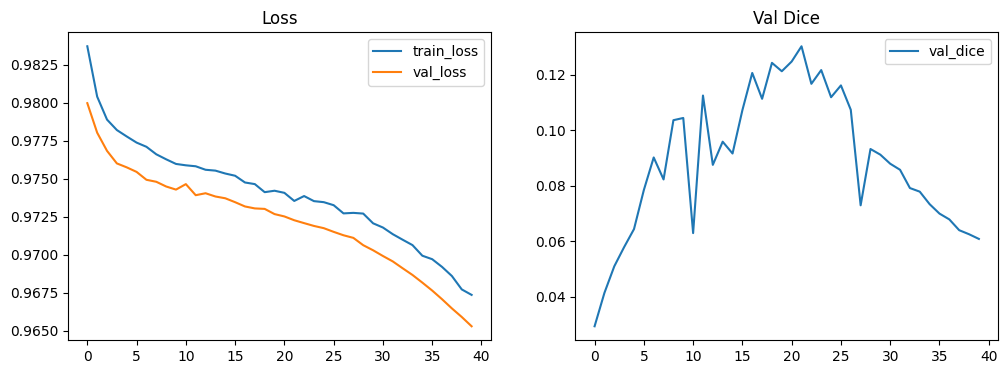

monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.


Task1 eval: {'dice_mean': 0.06086166558289275, 'iou_mean': 0.03158821090066186, 'hausdorff_mean': 34.36948746129086}


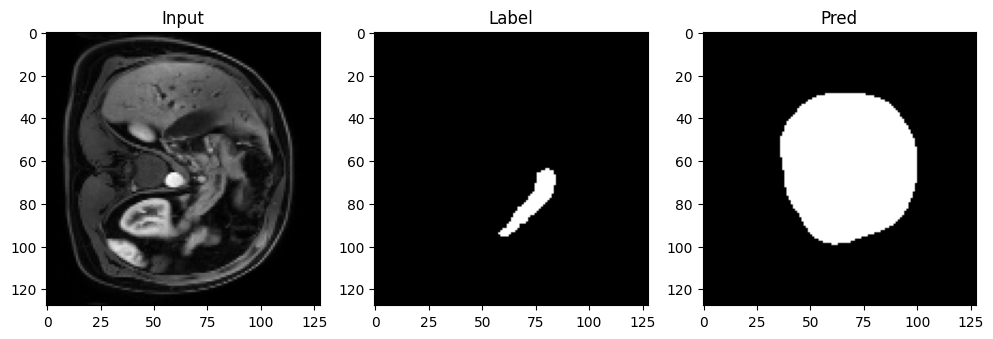

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Initialized Task2 model from Task1 weights (partial load).


RuntimeError: applying transform <monai.transforms.io.dictionary.LoadImaged object at 0x00000200685779A0>

In [16]:
results = run_task1_and_task2()

# Print evaluation metrics
print("Task 1 Results (T1 MRI segmentation):", results["metrics_task1"])
print("Task 2 Results (T2 MRI segmentation):", results["metrics_task2"])

In [ ]:
# ----------------------
# Extended Evaluation Metrics
# ----------------------
import numpy as np
from monai.metrics import SurfaceDistanceMetric
from monai.transforms import AsDiscrete

def extended_evaluation(model, val_loader, device=CONFIG["device"]):
    model.eval()
    post_pred = AsDiscrete(threshold=0.5)
    post_label = AsDiscrete(threshold=0.5)

    # Metric lists
    dice_list, iou_list = [], []
    precision_list, recall_list, specificity_list, f1_list = [], [], [], []
    haus_list, asd_list, vs_list = [], [], []

    haus_metric = HausdorffDistanceMetric(include_background=False, percentile=95)
    asd_metric = SurfaceDistanceMetric(include_background=False, symmetric=True)

    smooth = 1e-5

    with torch.no_grad():
        for batch in val_loader:
            imgs = batch["image"].to(device).float()
            labels = batch["label"].to(device).float()
            outputs = model(imgs)
            preds = post_pred(outputs)
            labs = post_label(labels)

            preds_n = preds.cpu().numpy().astype(np.uint8)
            labs_n = labs.cpu().numpy().astype(np.uint8)

            for p, l in zip(preds_n, labs_n):
                p = p[0]; l = l[0]

                tp = np.sum((p == 1) & (l == 1))
                tn = np.sum((p == 0) & (l == 0))
                fp = np.sum((p == 1) & (l == 0))
                fn = np.sum((p == 0) & (l == 1))

                dice = (2 * tp) / (2 * tp + fp + fn + smooth)
                iou = tp / (tp + fp + fn + smooth)
                precision = tp / (tp + fp + smooth)
                recall = tp / (tp + fn + smooth)
                specificity = tn / (tn + fp + smooth)
                f1 = (2 * precision * recall) / (precision + recall + smooth)
                volume_similarity = 1 - abs(p.sum() - l.sum()) / (p.sum() + l.sum() + smooth)

                dice_list.append(dice)
                iou_list.append(iou)
                precision_list.append(precision)
                recall_list.append(recall)
                specificity_list.append(specificity)
                f1_list.append(f1)
                vs_list.append(volume_similarity)

            # Compute distance-based metrics
            try:
                hd = haus_metric(preds.cpu(), labs.cpu())
                asd = asd_metric(preds.cpu(), labs.cpu())
                haus_list.append(float(hd.item()))
                asd_list.append(float(asd.item()))
            except Exception:
                haus_list.append(np.nan)
                asd_list.append(np.nan)

    return {
        "dice_mean": float(np.nanmean(dice_list)),
        "iou_mean": float(np.nanmean(iou_list)),
        "precision_mean": float(np.nanmean(precision_list)),
        "recall_mean": float(np.nanmean(recall_list)),
        "specificity_mean": float(np.nanmean(specificity_list)),
        "f1_mean": float(np.nanmean(f1_list)),
        "volume_similarity": float(np.nanmean(vs_list)),
        "hausdorff_mean": float(np.nanmean(haus_list)),
        "avg_surface_distance": float(np.nanmean(asd_list))
    }

# Example usage:
# metrics = extended_evaluation(model, val_loader)
# print(json.dumps(metrics, indent=2))
